In [13]:
import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd

In [14]:
with open("./ladder_results.json", 'r') as f:
    jsdata = json.load(f)
meta = jsdata['meta']
data = jsdata['results']
df = pd.DataFrame(data)
df

,dataset,alg,shuffle_frac,alpha,NS,SNS
0,auto-mpg,ISOMAP,0.0,5.704319,0.993227,0.342639
1,auto-mpg,LLE,0.0,5.704319,0.999668,0.437749
2,auto-mpg,PCA,0.0,5.704319,0.996494,0.289939
3,auto-mpg,MDS,0.0,5.704319,0.996407,0.287294
4,auto-mpg,UMAP,0.0,5.704319,0.947908,0.537960
...,...,...,...,...,...,...
7723,wine,PCA,0.9,0.341028,0.999566,0.706857
7724,wine,MDS,0.9,0.341028,0.999447,0.700957
7725,wine,UMAP,0.9,0.341028,0.997080,0.737176
7726,wine,TSNE,0.9,0.341028,0.992547,0.759364


In [15]:
def plot_stress_ladder(dataset):
    df_sub = df[df["dataset"] == dataset]

    styles = {
        'TSNE': ('d', '-', 8),
        'UMAP': ('s', '-', 7),
        'MDS': ('^', ':', 6),
        'ISOMAP': ('v', '-.', 6),
        'LLE': ('<', '--', 6),
        'PCA': ('>', ':', 6),
        'RANDOM': ('o', '--', 7),
    }

    display_name = {
        'ISOMAP': 'ISO',
    }

    fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)


    # Plot NS on ax1
    # for alg in df_sub["alg"].unique():
    for alg in styles.keys():
        marker, linestyle, markersize = styles[alg]
        sub_alg = df_sub[df_sub["alg"] == alg]
        if sub_alg.empty:
            continue
        for ax, metric in zip(axes, ['NS', 'SNS']):
            label = display_name.get(alg, alg)
            ax.plot(sub_alg["shuffle_frac"], sub_alg[metric], marker=marker, linestyle=linestyle, markersize=markersize, alpha=1, label=label)
            ax.set_title(metric)
    

    fig.suptitle(dataset, fontsize=25)
    plt.legend()
    plt.tight_layout()

    return fig


/var/folders/y6/1d6nhf8n2hqfq_qz0hk_hpfr0000gn/T/ipykernel_36760/303605766.py:18: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=True)


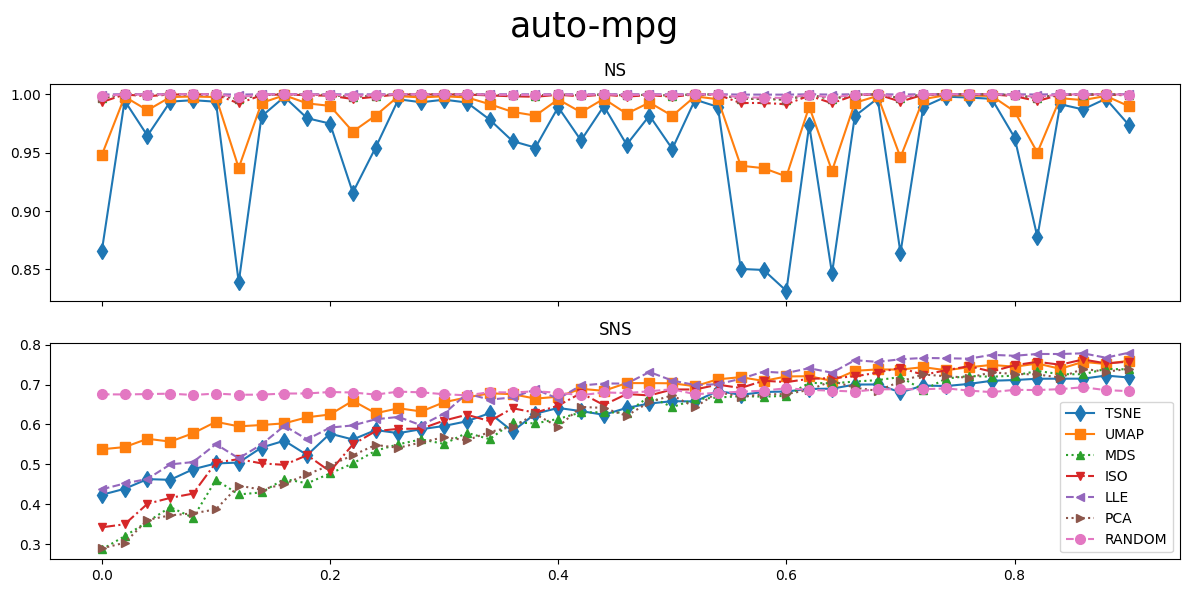

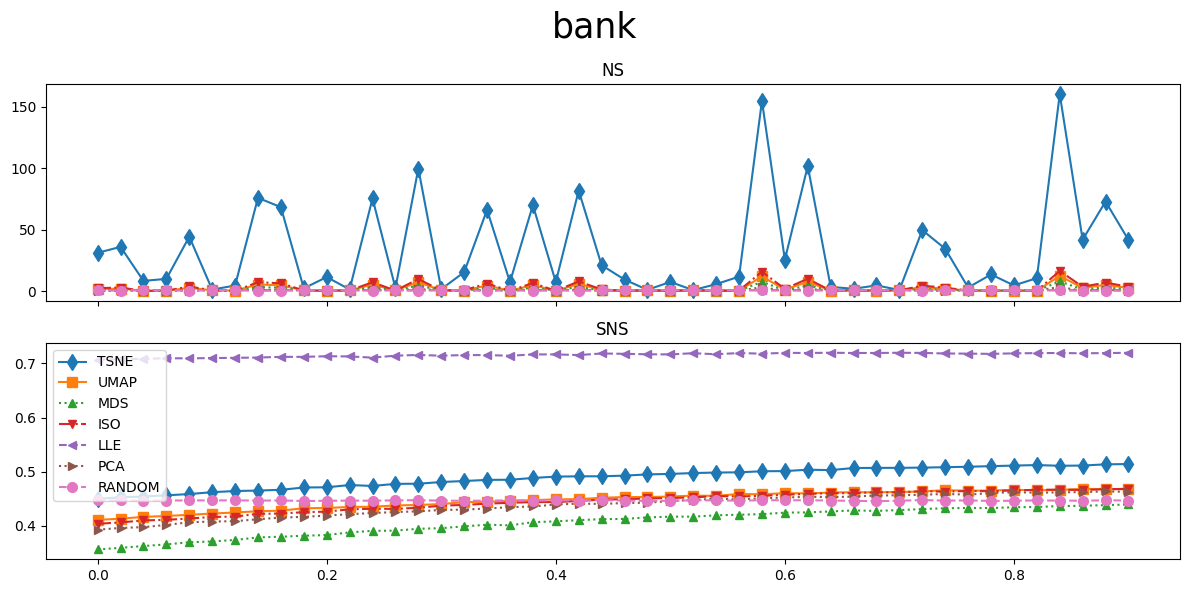

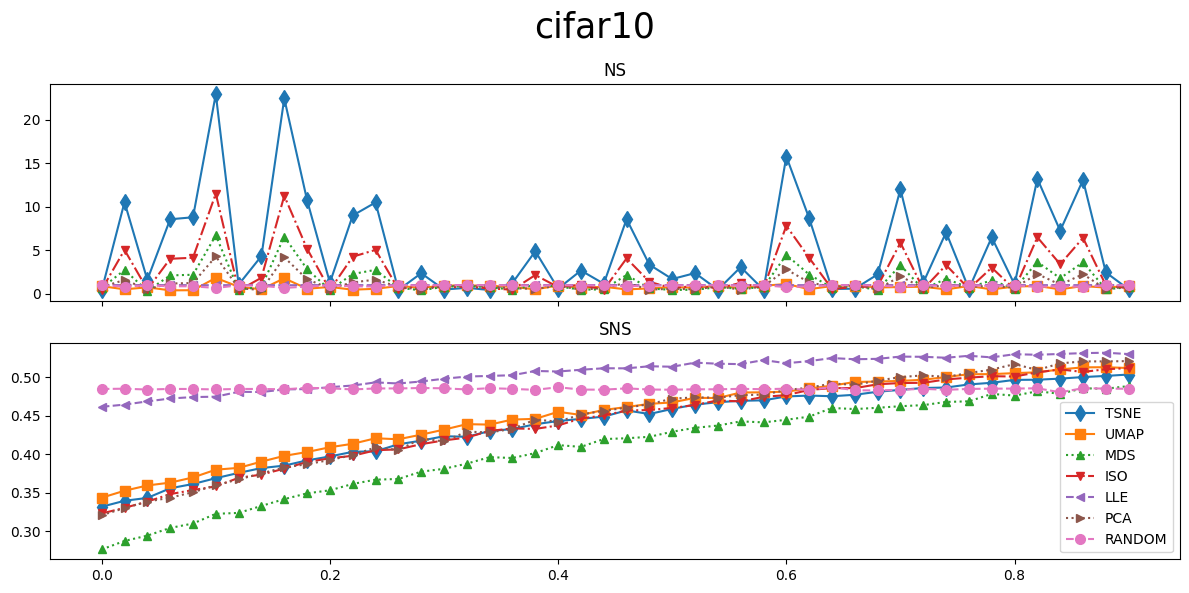

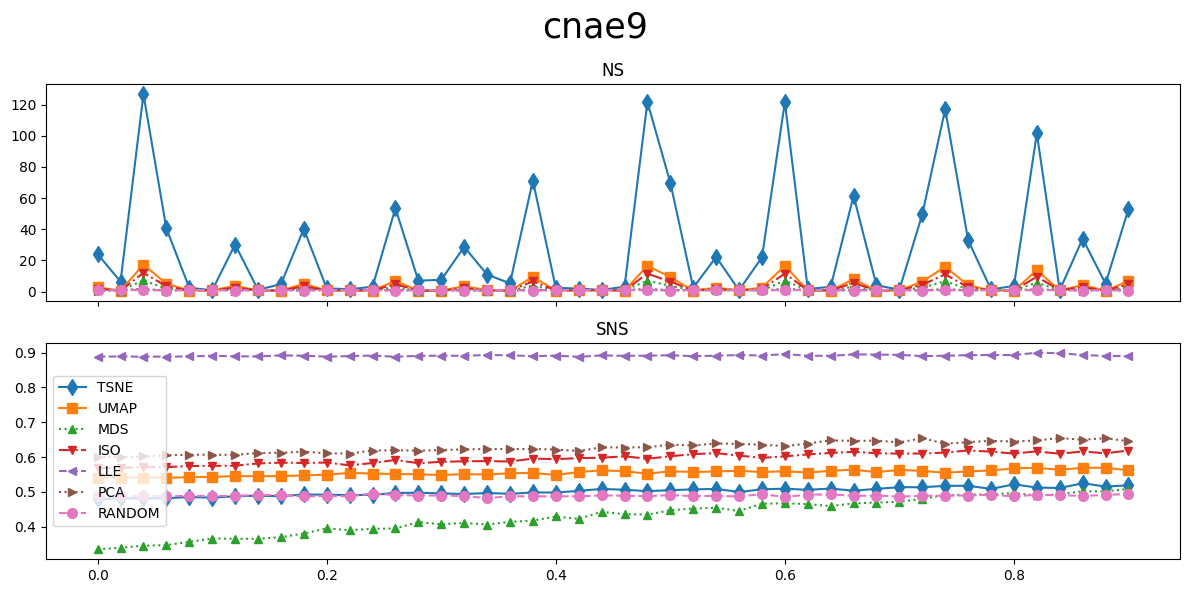

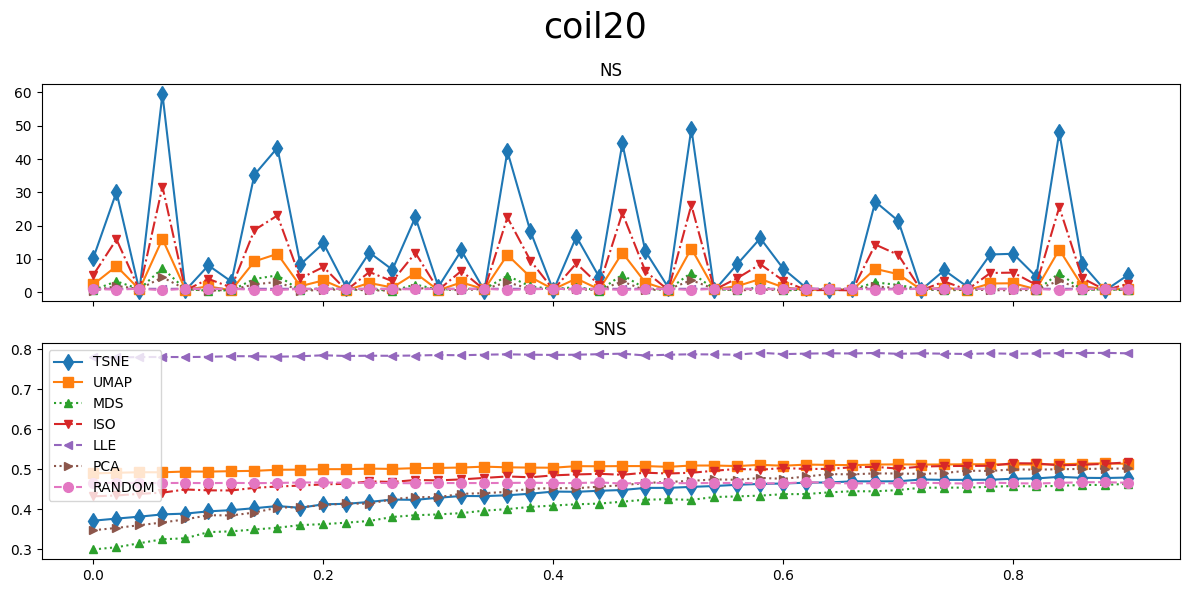

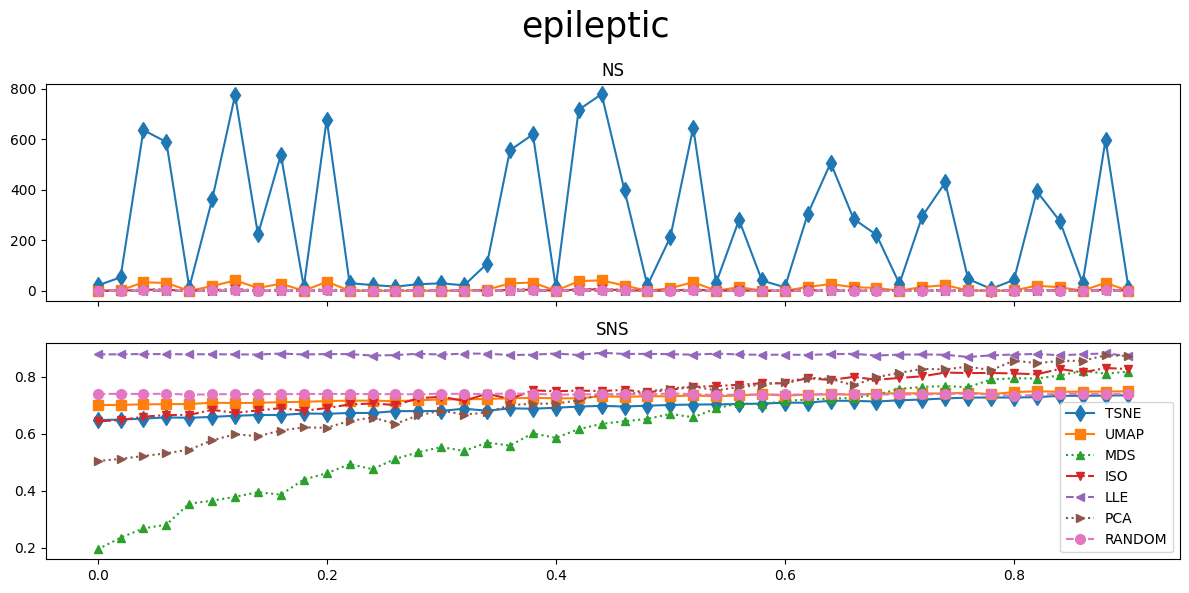

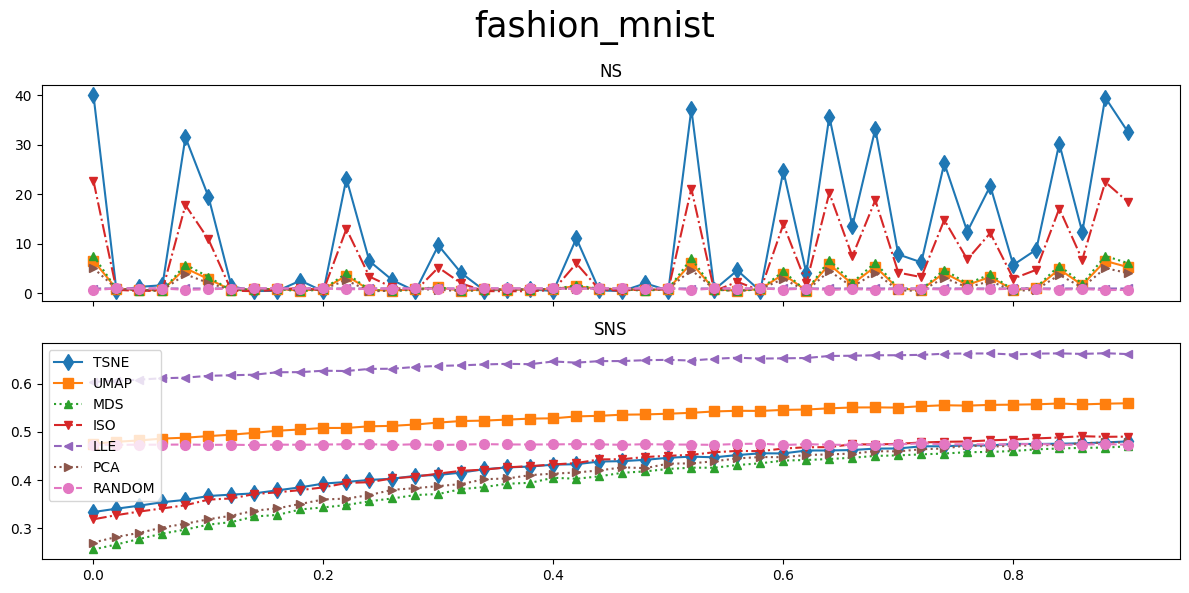

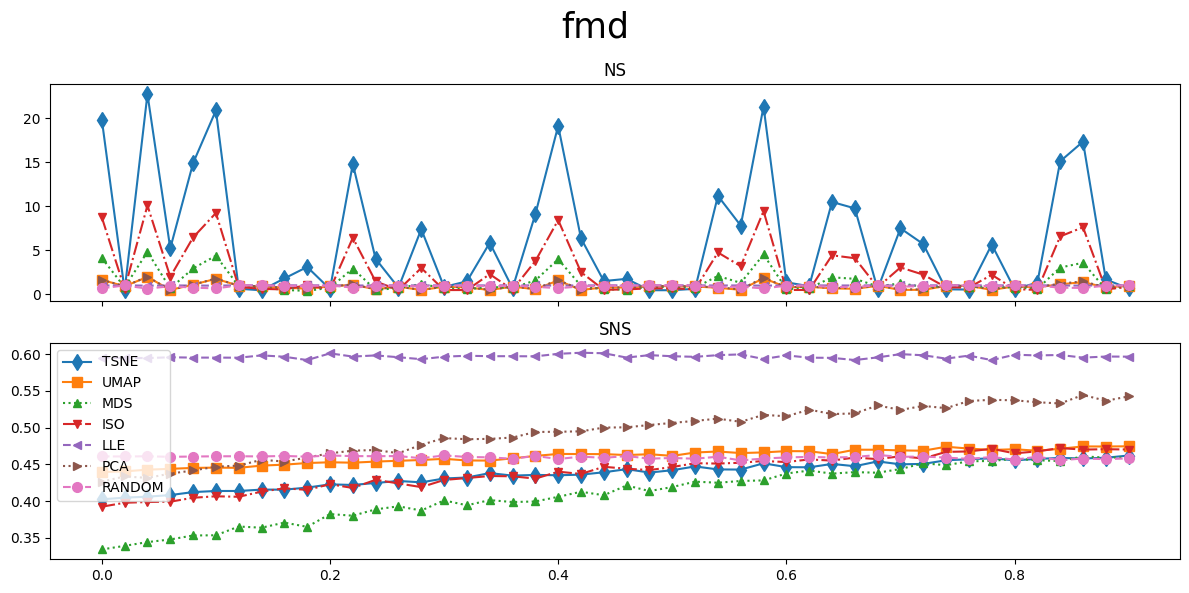

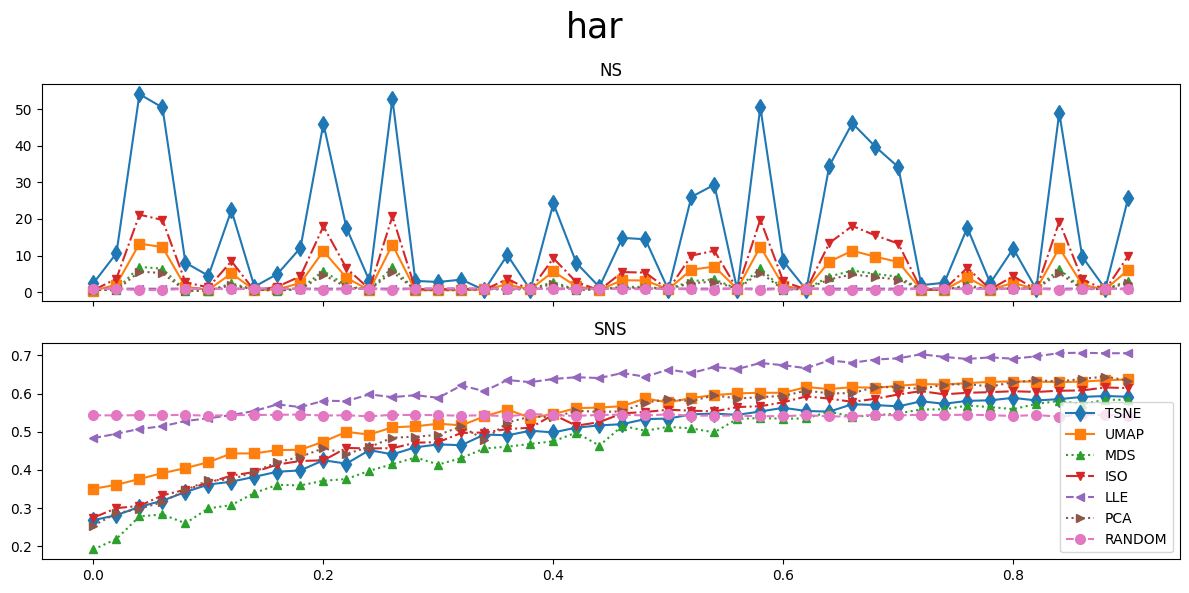

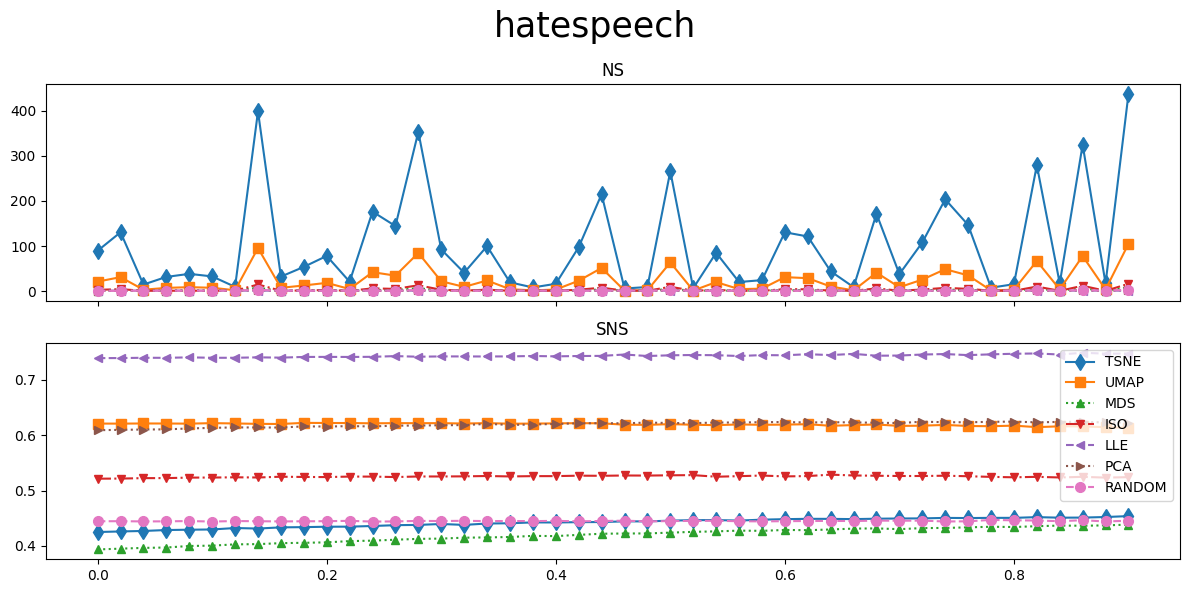

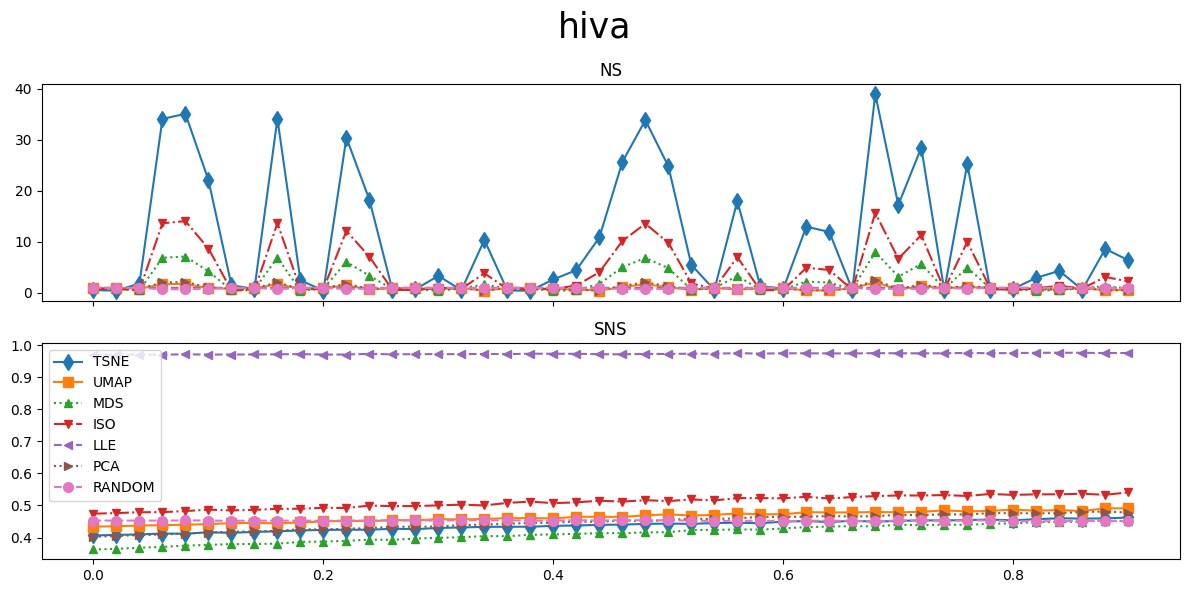

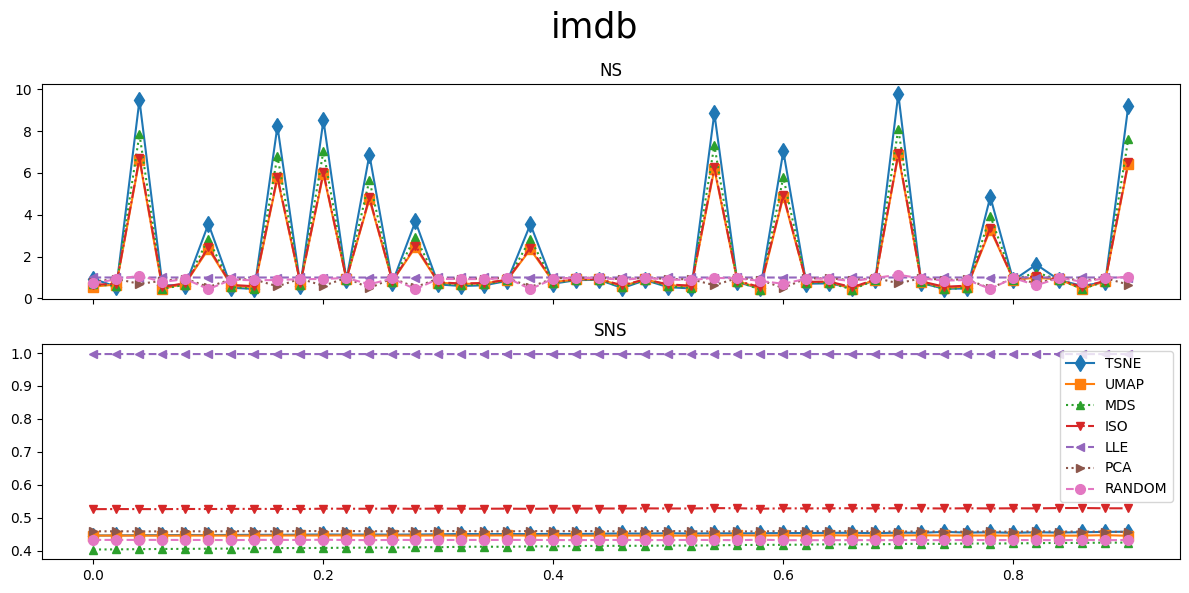

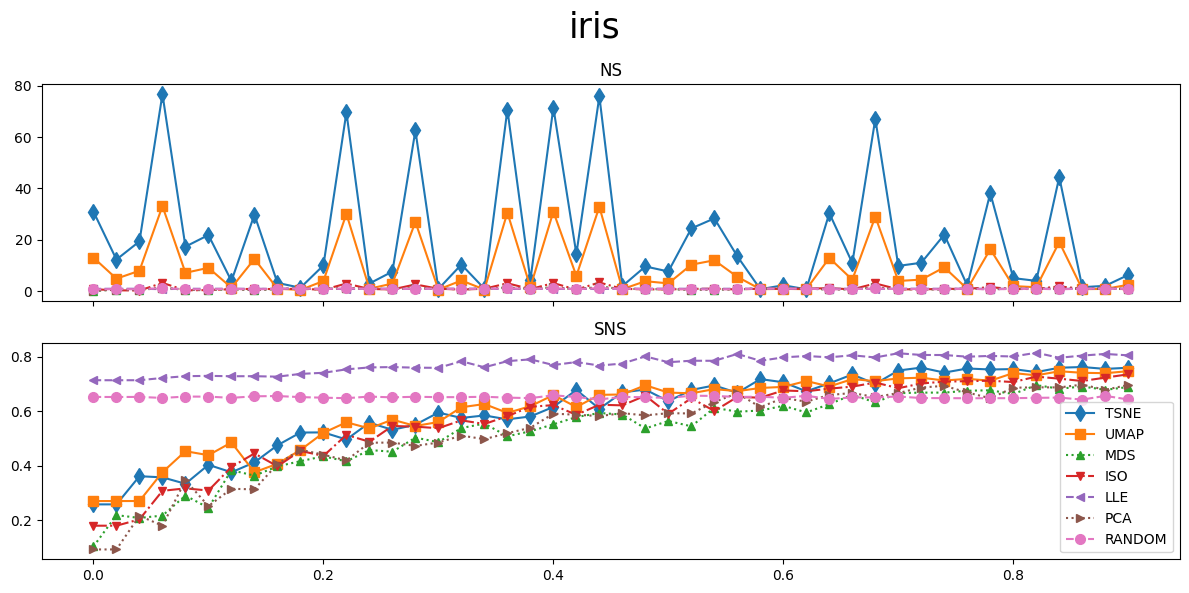

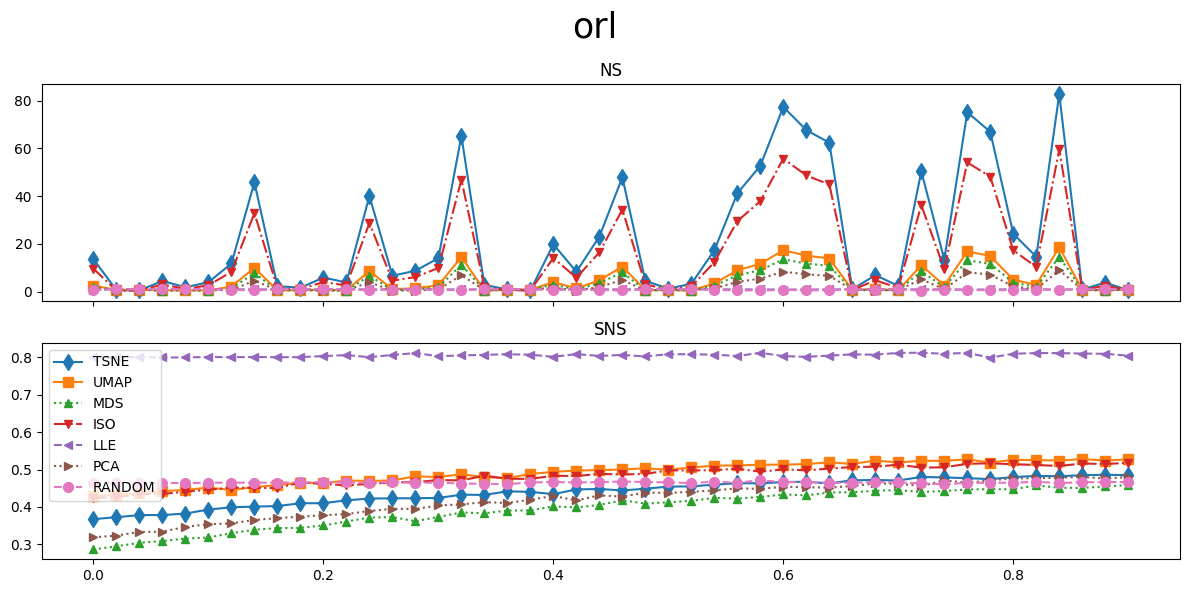

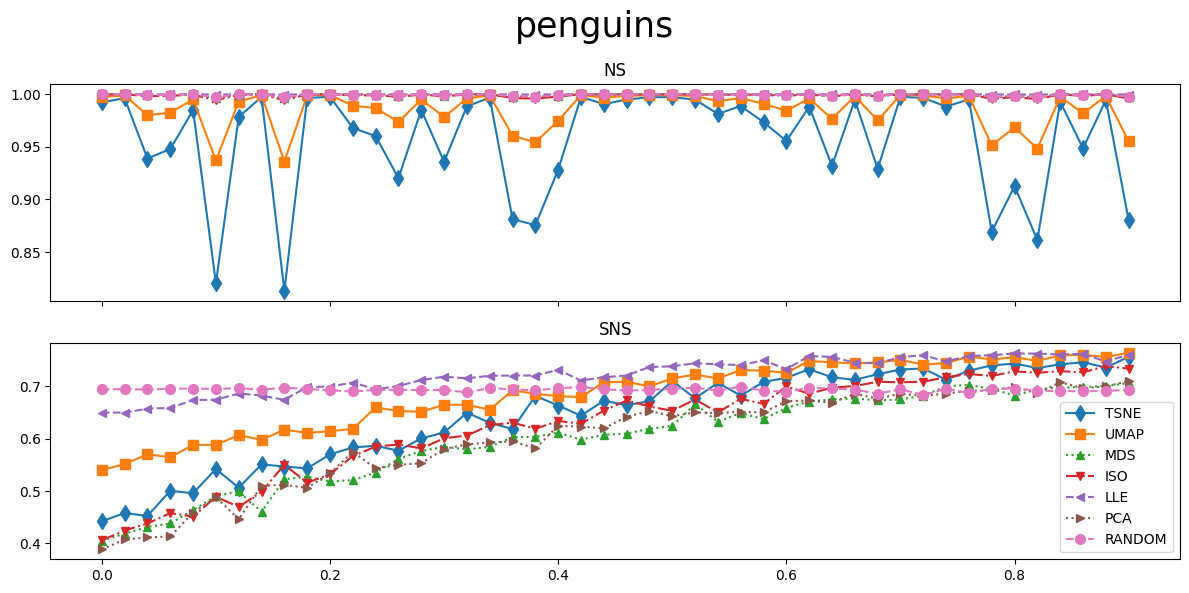

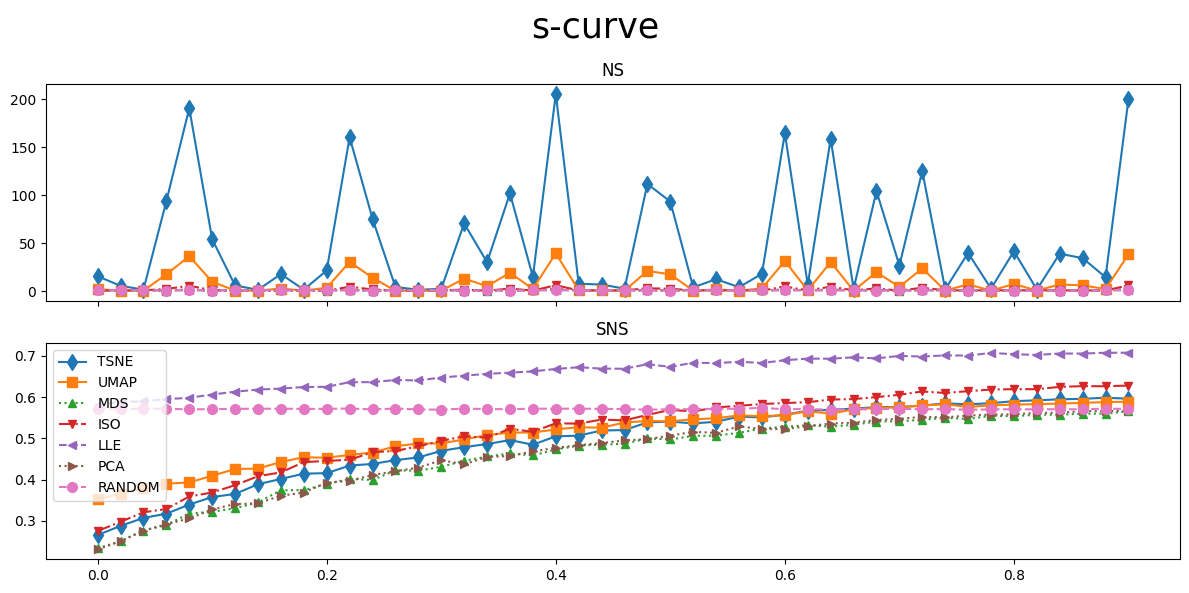

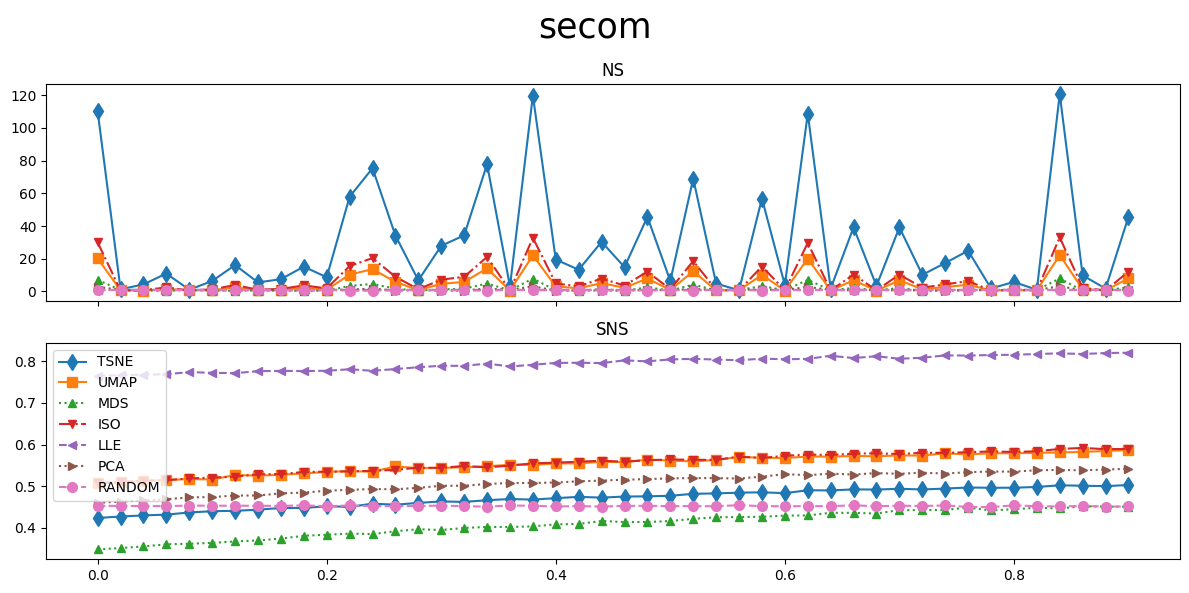

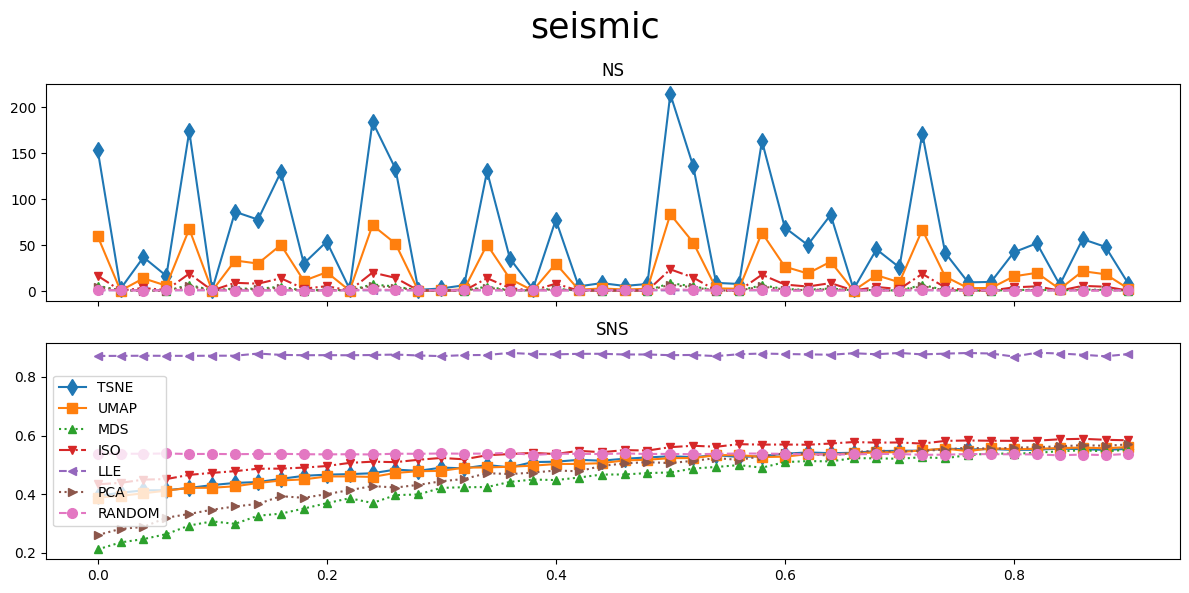

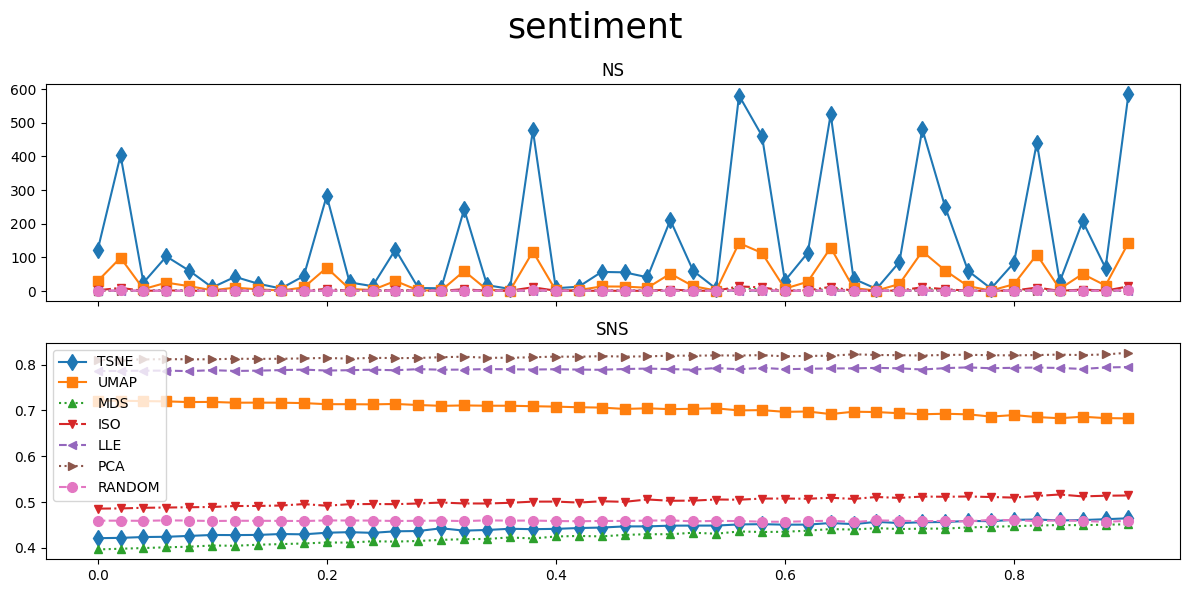

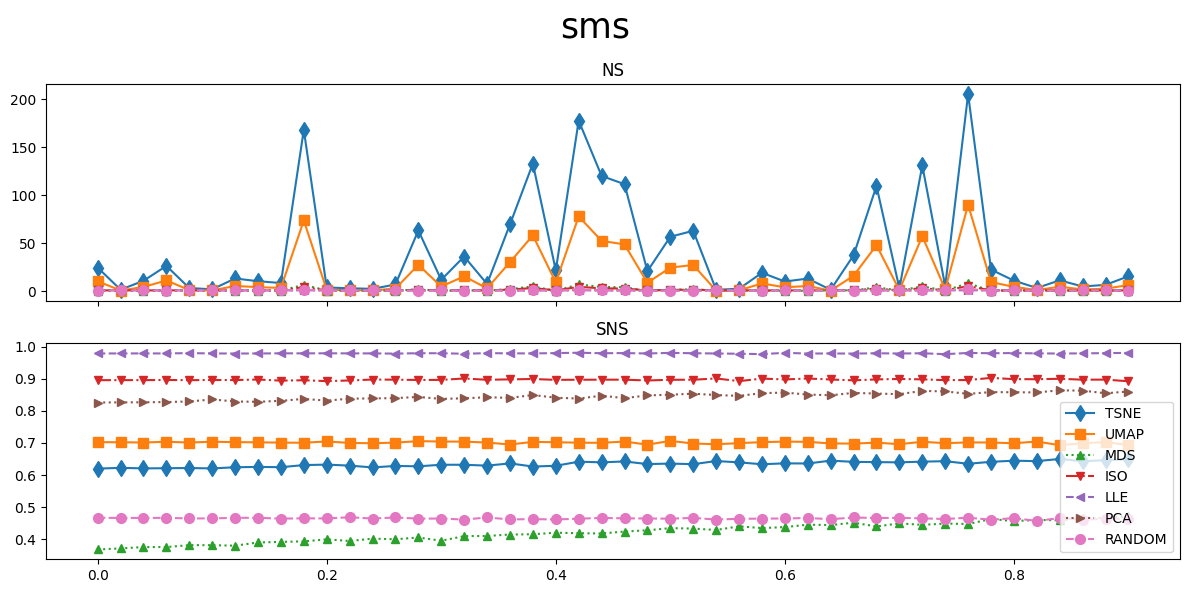

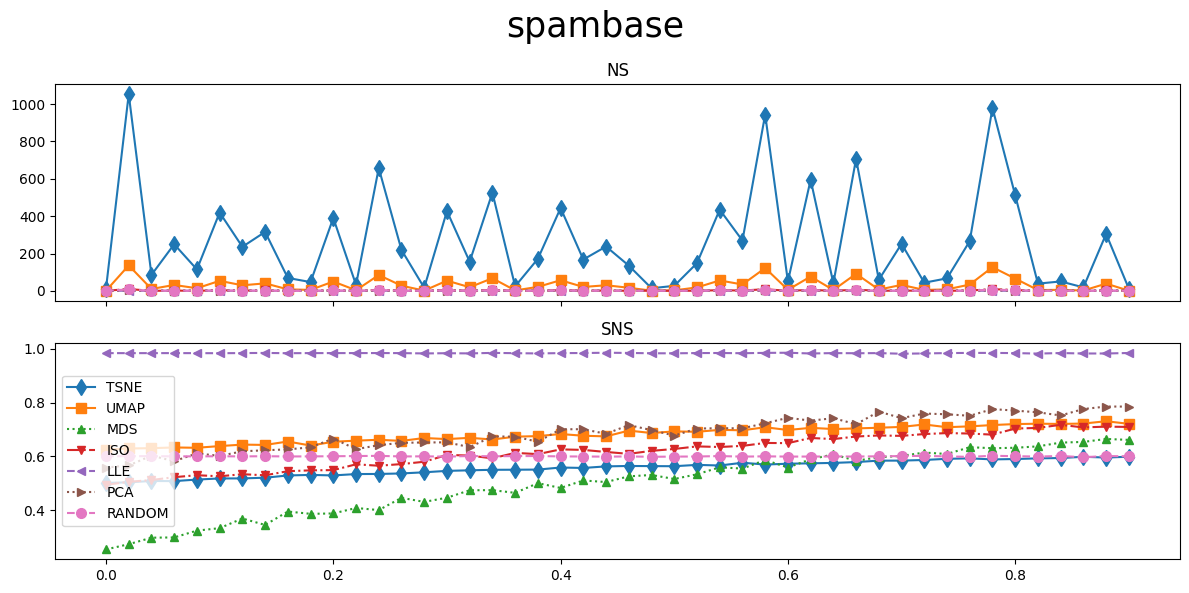

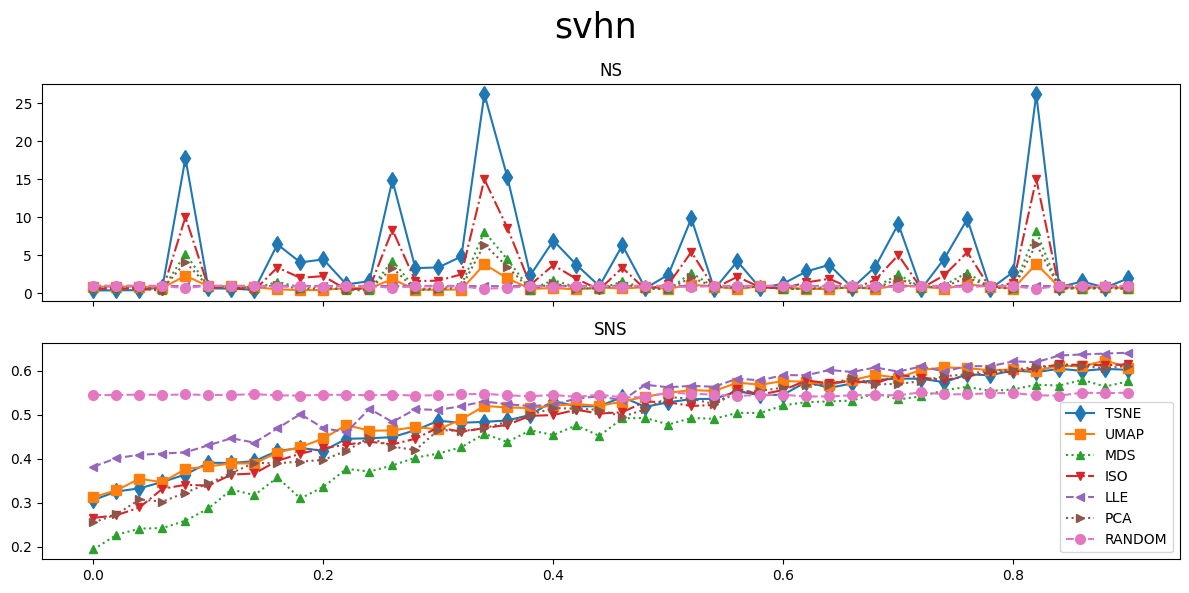

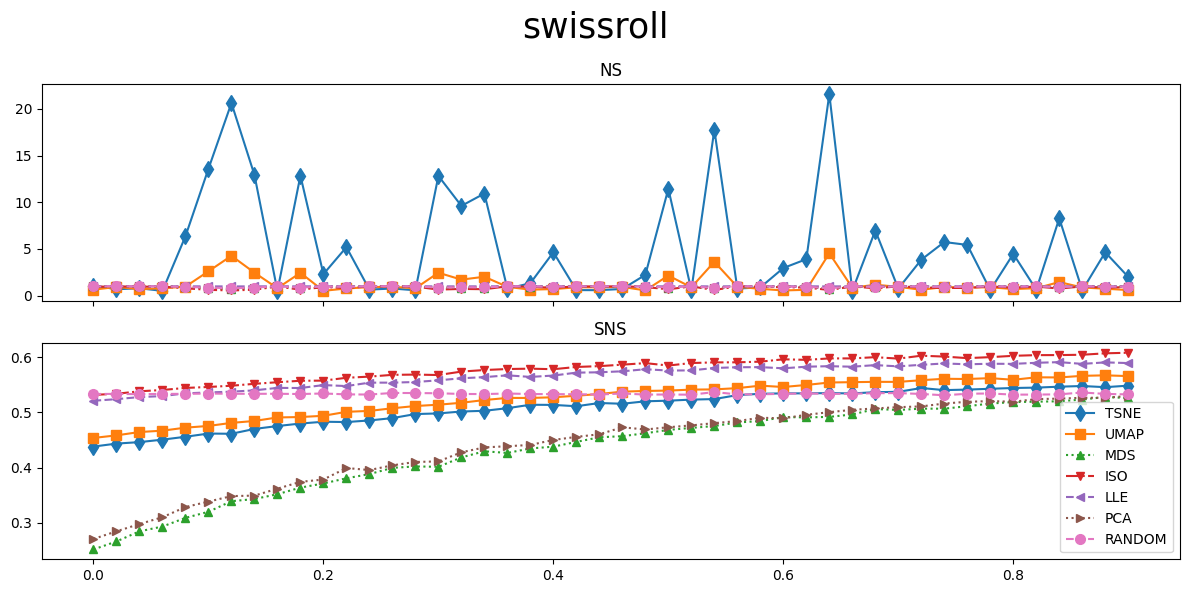

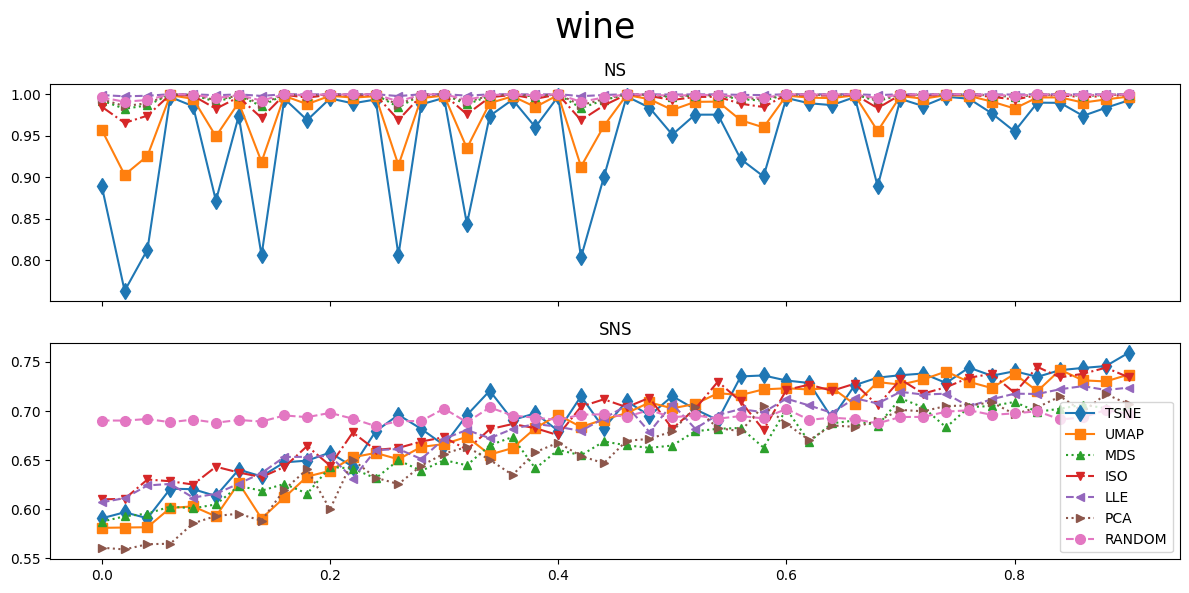

In [16]:
from pathlib import Path
figs_dir = Path("perturb_figs")
figs_dir.mkdir(parents=True, exist_ok=True)


for dataset in df['dataset'].unique():
    fig = plot_stress_ladder(dataset)
    fig.savefig(figs_dir / f"{dataset}.png", format='png')
    # plt.close()
    